# Agricultural Policy Insights

This project uses production, market price, and seed price data to answer a small number of clear, defensible questions for producers and agricultural-policy institutions, rather than broad exploratory analysis. The aim is focused findings that can support decision-making.

## Core Questions

1. Has the relationship between the seed price and the market price worsened over the years?
2. Is higher regional yield associated with lower selling price within the same year?
3. Can next-season sales price and margin be predicted from historical trends?
4. Which region offers the best net margin per hectare for each crop, and where is it most profitable to plant?

In [1]:
import subprocess
import sys
from pathlib import Path
import pandas as pd

DATASET_PATH = Path("data/dataset.csv")
PIPELINE_SCRIPT = Path("scripts/run_pipeline.py")

if not DATASET_PATH.exists():
    print(f"{DATASET_PATH} not found - running pipeline...")
    result = subprocess.run([sys.executable, str(PIPELINE_SCRIPT)])
    if result.returncode != 0:
        raise RuntimeError("Pipeline failed - check output above.")
else:
    print(f"{DATASET_PATH} found - loading directly.")

data\dataset.csv found - loading directly.


In [2]:
df = pd.read_csv(DATASET_PATH)
df.head()

,Year,Crop,Region,Area (ha),Total production (t),Yield (t/ha),Selling price (RSD/kg),Seed price (RSD/kg)
0,2010,Barley,Belgrade Region,7297.0,23371.0,3.2,15.95,NaN
1,2010,Corn,Belgrade Region,43090.0,259374.0,6.0,16.22,278.43
2,2010,Wheat,Belgrade Region,33256.0,111077.0,3.3,15.46,NaN
3,2010,Barley,Southern and Eastern Serbia Region,22141.0,53382.0,2.4,18.21,NaN
4,2010,Corn,Southern and Eastern Serbia Region,180470.0,952110.0,5.3,16.85,270.65


In [3]:
# Shared setup for the hypothesis cells
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

# One color per crop, used across all figures.
CROP_COLORS = {"Barley": "tab:blue", "Corn": "tab:orange", "Wheat": "tab:green"}

analysis_df = df.copy()

analysis_df["Margin ratio"] = analysis_df["Selling price (RSD/kg)"] / analysis_df["Seed price (RSD/kg)"]

# Seed price -> cost per ha. Corn sown by seed count (~75,000/ha = 30 kg at
# 400 g/1000 kernels); wheat/barley by weight. See README for sources.
SEEDING_RATE_KG_HA = {"Corn": 30, "Wheat": 225, "Barley": 190}

analysis_df["Seeding rate (kg/ha)"] = analysis_df["Crop"].map(SEEDING_RATE_KG_HA)
analysis_df["Seed cost per ha (RSD/ha)"] = analysis_df["Seed price (RSD/kg)"] * analysis_df["Seeding rate (kg/ha)"]
analysis_df["Gross revenue per ha (RSD/ha)"] = analysis_df["Selling price (RSD/kg)"] * analysis_df["Yield (t/ha)"] * 1000
analysis_df["Net margin per ha (RSD/ha)"] = analysis_df["Gross revenue per ha (RSD/ha)"] - analysis_df["Seed cost per ha (RSD/ha)"]


# Consumer Price Index (CPI), annual average, rebased to 2010=100; used to
# deflate per-hectare money to constant 2010 dinars.
import sys
if "scripts" not in sys.path:
    sys.path.insert(0, "scripts")
from paths import CPI_CLEAN

cpi_2010 = (
    pd.read_csv(CPI_CLEAN)
    .groupby("Year")["CPI index (2006=100)"].mean()
    .pipe(lambda s: s / s.loc[2010] * 100)
    .rename("CPI (2010=100)")
    .reset_index()
)


,Year,Crop,Median selling price (RSD/kg),Median seed price (RSD/kg),Median margin ratio,Median seed cost per ha (RSD/ha),Median gross revenue per ha (RSD/ha),Median net margin per ha (RSD/ha)
0,2010,Corn,16.420,271.965,0.059536,8158.950000,99351.000000,91075.350000
1,2011,Barley,24.050,35.800,0.683987,6120.352055,80379.783855,74652.638775
2,2011,Corn,22.510,296.010,0.075888,7990.379646,105321.883085,97549.611839
3,2011,Wheat,25.100,36.610,0.680835,7411.771533,91523.197560,84113.450549
4,2012,Barley,26.675,37.500,0.709482,5973.129831,80262.098251,74682.398571


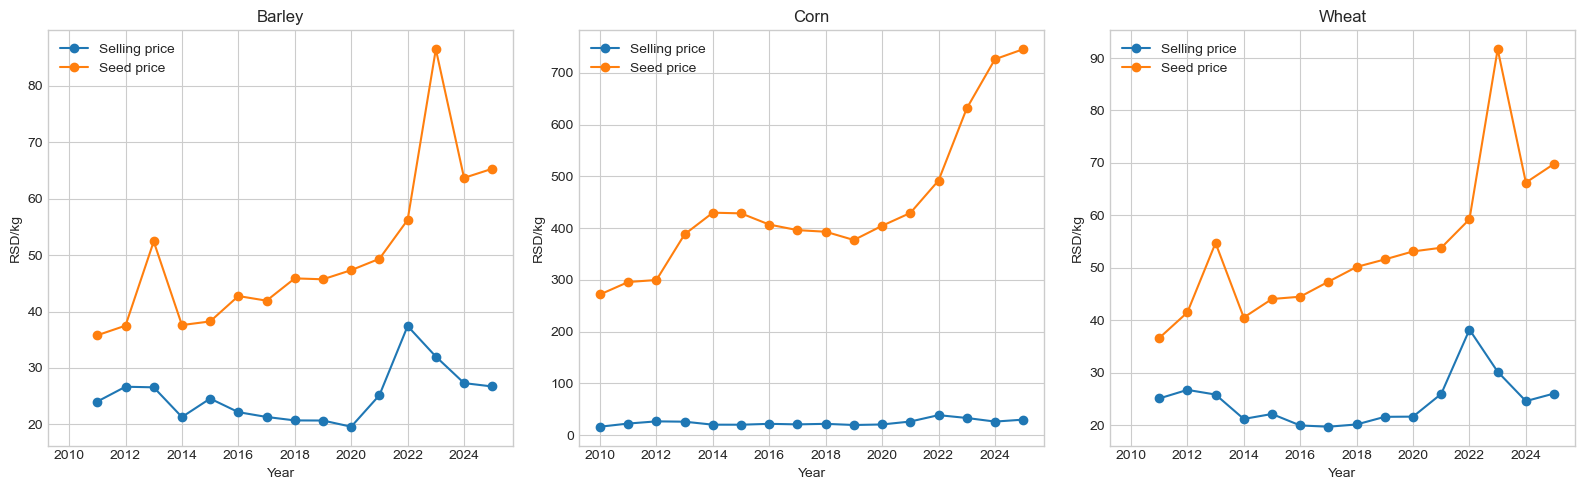

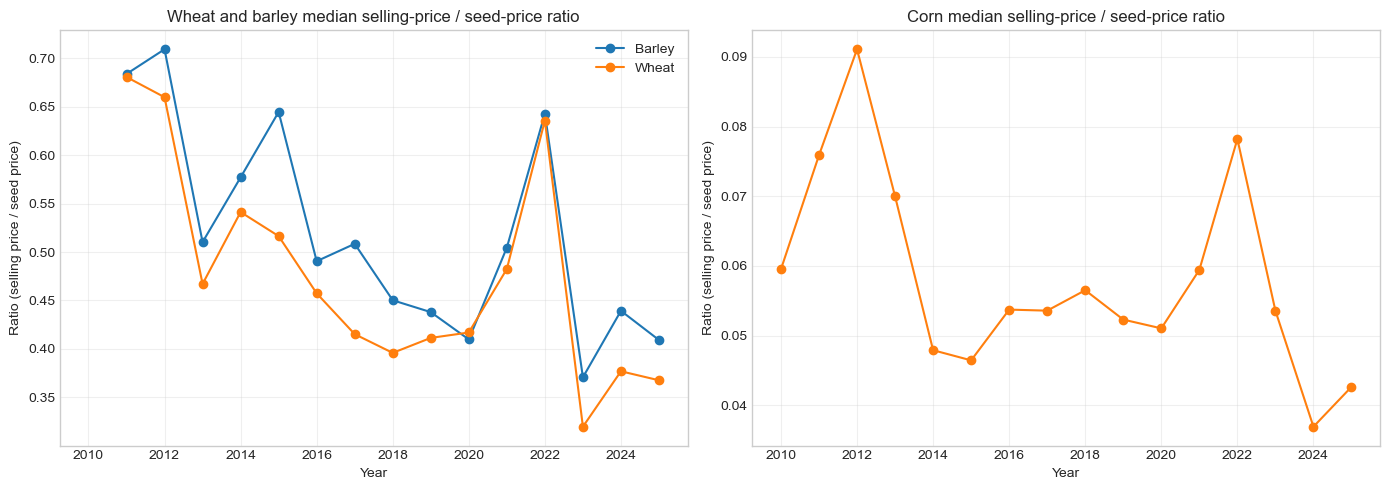

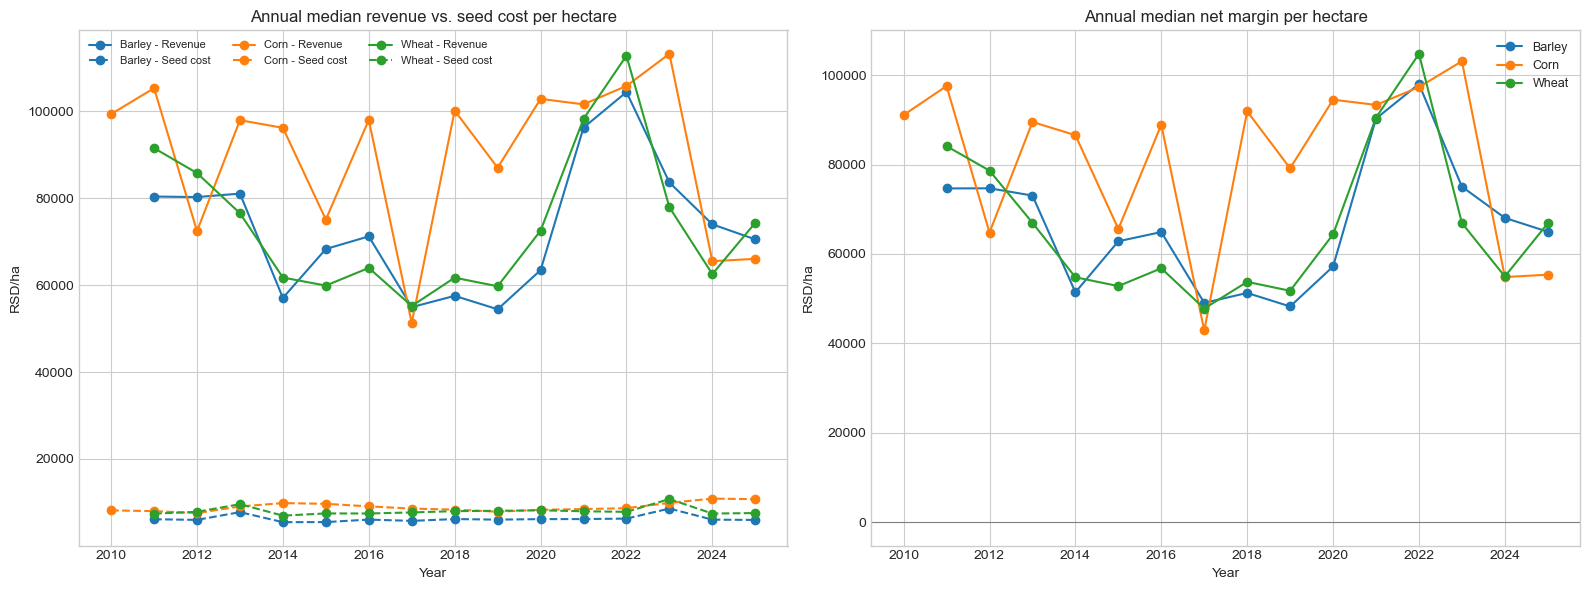

,"Net margin, 2010-2012","Net margin, 2023-2025",Change %
Crop,,,
Barley,74667.5,69356.9,-7.1
Corn,84468.9,71096.5,-15.8
Wheat,81373.5,62906.7,-22.7


In [4]:
# Hypothesis 1: did the selling-price to seed-price relationship weaken over time?
annual_margin = (
    analysis_df.dropna(subset=["Selling price (RSD/kg)", "Seed price (RSD/kg)"])
    .groupby(["Year", "Crop"])
    .agg(**{
        "Median selling price (RSD/kg)": ("Selling price (RSD/kg)", "median"),
        "Median seed price (RSD/kg)": ("Seed price (RSD/kg)", "median"),
        "Median margin ratio": ("Margin ratio", "median"),
        "Median seed cost per ha (RSD/ha)": ("Seed cost per ha (RSD/ha)", "median"),
        "Median gross revenue per ha (RSD/ha)": ("Gross revenue per ha (RSD/ha)", "median"),
        "Median net margin per ha (RSD/ha)": ("Net margin per ha (RSD/ha)", "median"),
    })
    .reset_index()
)
# Deflate per-hectare money to constant 2010 dinars. Per-kg prices stay nominal (actual
# price each year), and the selling/seed ratio is invariant to deflation anyway.
annual_margin = annual_margin.merge(cpi_2010, on="Year", how="left")
for _col in ["Median gross revenue per ha (RSD/ha)",
             "Median seed cost per ha (RSD/ha)",
             "Median net margin per ha (RSD/ha)"]:
    annual_margin[_col] = annual_margin[_col] / (annual_margin["CPI (2010=100)"] / 100)
annual_margin = annual_margin.drop(columns="CPI (2010=100)")

display(annual_margin.head())


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)
for ax, crop in zip(axes, sorted(annual_margin["Crop"].unique())):
    subset = annual_margin[annual_margin["Crop"] == crop]
    ax.plot(subset["Year"], subset["Median selling price (RSD/kg)"], marker="o", label="Selling price")
    ax.plot(subset["Year"], subset["Median seed price (RSD/kg)"], marker="o", label="Seed price")
    ax.set_title(crop)
    ax.set_xlabel("Year")
    ax.set_ylabel("RSD/kg")
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

wheat_barley = annual_margin[annual_margin["Crop"].isin(["Wheat", "Barley"])]
for crop, subset in wheat_barley.groupby("Crop"):
    axes[0].plot(subset["Year"], subset["Median margin ratio"], marker="o", label=crop)
axes[0].set_title("Wheat and barley median selling-price / seed-price ratio")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Ratio (selling price / seed price)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

corn = annual_margin[annual_margin["Crop"] == "Corn"]
axes[1].plot(corn["Year"], corn["Median margin ratio"], marker="o", color="tab:orange")
axes[1].set_title("Corn median selling-price / seed-price ratio")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Ratio (selling price / seed price)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-hectare money: revenue (solid) vs seed cost (dashed) per crop; net margin at right.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for crop, subset in annual_margin.groupby("Crop"):
    color = CROP_COLORS[crop]
    ax.plot(subset["Year"], subset["Median gross revenue per ha (RSD/ha)"], marker="o",
            color=color, linestyle="-", label=f"{crop} - Revenue")
    ax.plot(subset["Year"], subset["Median seed cost per ha (RSD/ha)"], marker="o",
            color=color, linestyle="--", label=f"{crop} - Seed cost")
ax.set_title("Annual median revenue vs. seed cost per hectare")
ax.set_xlabel("Year")
ax.set_ylabel("RSD/ha")
ax.legend(fontsize=8, ncol=3, loc="upper left")

ax2 = axes[1]
for crop, subset in annual_margin.groupby("Crop"):
    color = CROP_COLORS[crop]
    ax2.plot(subset["Year"], subset["Median net margin per ha (RSD/ha)"], marker="o",
             color=color, label=crop)
ax2.axhline(0, color="grey", linewidth=0.8)
ax2.set_title("Annual median net margin per hectare")
ax2.set_xlabel("Year")
ax2.set_ylabel("RSD/ha")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Early (2010-2012) vs recent (2023-2025) change in net margin per hectare.
# 3-year windows are used instead of single endpoint years so a one-off high or
# low year (e.g. the 2022 price spike) does not distort the comparison.
early_years, recent_years = [2010, 2011, 2012], [2023, 2024, 2025]
_early = annual_margin[annual_margin["Year"].isin(early_years)].groupby("Crop")["Median net margin per ha (RSD/ha)"].mean()
_recent = annual_margin[annual_margin["Year"].isin(recent_years)].groupby("Crop")["Median net margin per ha (RSD/ha)"].mean()
margin_change = pd.DataFrame({"Net margin, 2010-2012": _early, "Net margin, 2023-2025": _recent})
margin_change["Change %"] = (margin_change["Net margin, 2023-2025"] / margin_change["Net margin, 2010-2012"] - 1) * 100
display(margin_change.round(1))


,Crop,Observations,"Correlation, raw","Correlation, demeaned"
1,Corn,64.0,-0.409006,-0.541848
2,Wheat,64.0,0.244398,-0.333003
0,Barley,63.0,0.309271,-0.180003


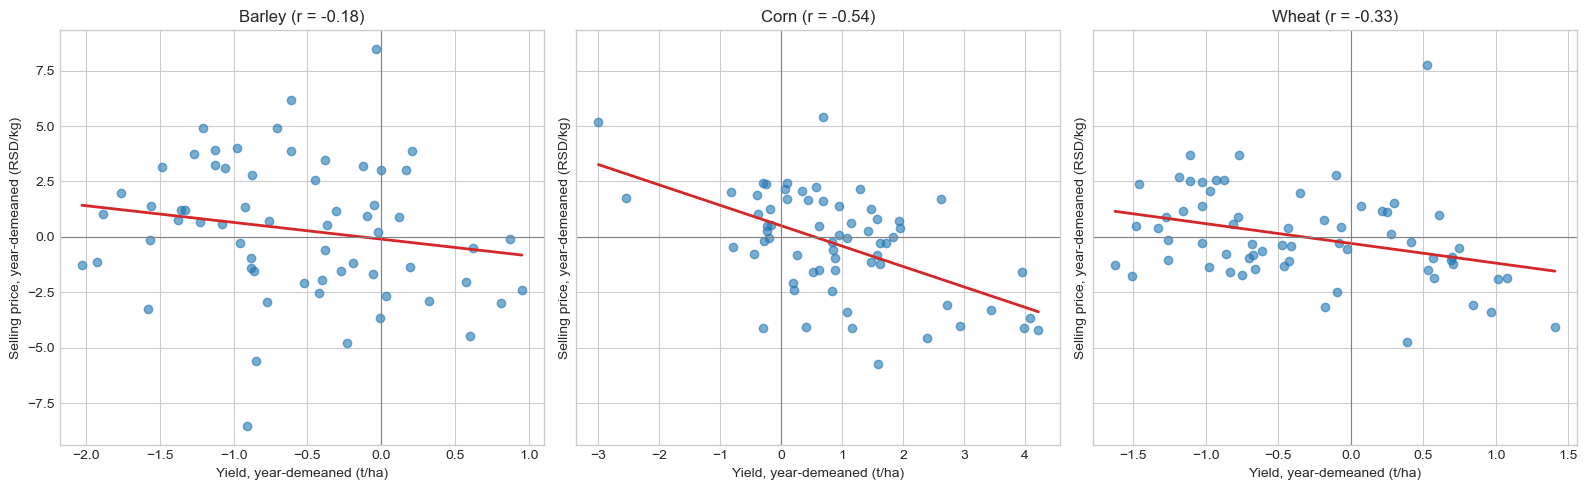

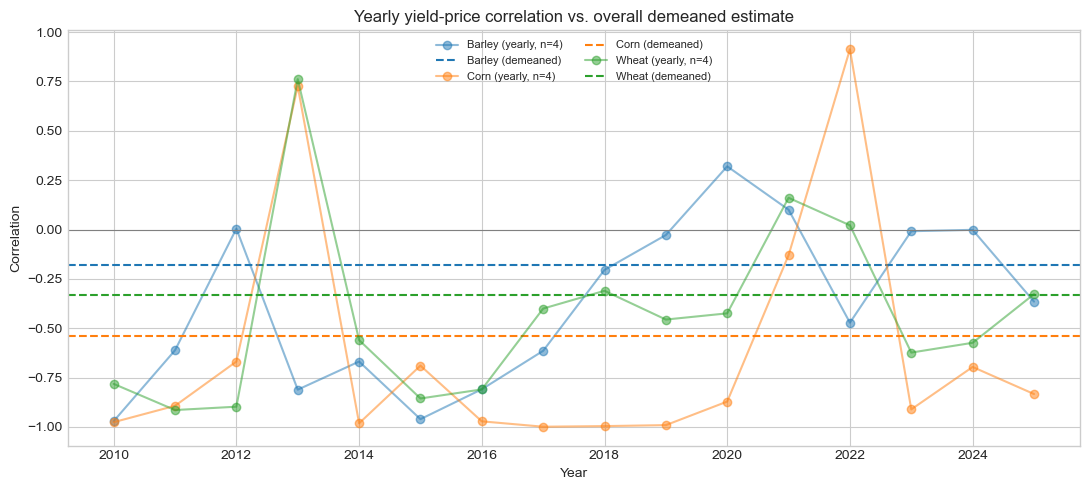

In [5]:
# Hypothesis 2: yield versus selling price, by crop
# Demean by year to strip across-year price trends, keeping within-year regional variation.
demeaned = analysis_df.dropna(subset=["Yield (t/ha)", "Selling price (RSD/kg)"]).copy()
demeaned["Yield, year-demeaned (t/ha)"] = demeaned.groupby("Year")["Yield (t/ha)"].transform(lambda s: s - s.mean())
demeaned["Selling price, year-demeaned (RSD/kg)"] = demeaned.groupby("Year")["Selling price (RSD/kg)"].transform(lambda s: s - s.mean())

yield_price_correlations = (
    demeaned.groupby("Crop")
    .apply(lambda frame: pd.Series({
        "Observations": len(frame),
        "Correlation, raw": frame["Yield (t/ha)"].corr(frame["Selling price (RSD/kg)"]),
        "Correlation, demeaned": frame["Yield, year-demeaned (t/ha)"].corr(frame["Selling price, year-demeaned (RSD/kg)"]),
    }), include_groups=False)
    .reset_index()
    .sort_values("Correlation, demeaned")
)
display(yield_price_correlations)

demeaned_corr = dict(zip(yield_price_correlations["Crop"], yield_price_correlations["Correlation, demeaned"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, crop in zip(axes, sorted(demeaned["Crop"].unique())):
    subset = demeaned[demeaned["Crop"] == crop]
    x = subset["Yield, year-demeaned (t/ha)"]
    y = subset["Selling price, year-demeaned (RSD/kg)"]
    ax.scatter(x, y, alpha=0.6)

    # OLS trend line
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="tab:red", linewidth=2)

    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_title(f"{crop} (r = {demeaned_corr[crop]:.2f})")
    ax.set_xlabel("Yield, year-demeaned (t/ha)")
    ax.set_ylabel("Selling price, year-demeaned (RSD/kg)")
plt.tight_layout()
plt.show()

# Robustness: yearly correlation (n=4, noisy) vs the overall demeaned estimate (dashed).
yearly_corr = (
    analysis_df.dropna(subset=["Yield (t/ha)", "Selling price (RSD/kg)"])
    .groupby(["Year", "Crop"])
    .filter(lambda g: len(g) >= 3)
    .groupby(["Year", "Crop"])
    .apply(lambda g: g["Yield (t/ha)"].corr(g["Selling price (RSD/kg)"]), include_groups=False)
    .rename("Yearly correlation")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for crop, subset in yearly_corr.groupby("Crop"):
    color = CROP_COLORS[crop]
    ax.plot(subset["Year"], subset["Yearly correlation"], marker="o", alpha=0.5,
            color=color, label=f"{crop} (yearly, n=4)")
    ax.axhline(demeaned_corr[crop], color=color, linestyle="--", linewidth=1.5,
               label=f"{crop} (demeaned)")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Yearly yield-price correlation vs. overall demeaned estimate")
ax.set_xlabel("Year")
ax.set_ylabel("Correlation")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


,Crop,Region,Forecast year,Predicted selling price (RSD/kg),Predicted margin ratio,Current selling price (RSD/kg),Current margin ratio,Latest year,History years
0,Barley,Belgrade Region,2026,45.662,0.561357,34.33,0.553710,2024,5
1,Barley,Southern and Eastern Serbia Region,2026,24.865,0.313519,26.72,0.409126,2025,5
2,Barley,Sumadija and Western Serbia Region,2026,31.967,0.387281,31.76,0.472478,2025,5
3,Barley,Vojvodina Region,2026,25.693,0.343119,24.90,0.408934,2025,5
4,Corn,Belgrade Region,2026,30.068,0.035761,29.79,0.045081,2025,5
5,Corn,Southern and Eastern Serbia Region,2026,33.147,0.031079,33.08,0.040838,2025,5
6,Corn,Sumadija and Western Serbia Region,2026,28.299,0.029640,30.33,0.044494,2025,5
7,Corn,Vojvodina Region,2026,23.210,0.017037,25.50,0.030980,2025,5
8,Wheat,Belgrade Region,2026,25.301,0.311521,26.68,0.375035,2025,5
9,Wheat,Southern and Eastern Serbia Region,2026,25.122,0.300739,25.42,0.360057,2025,5


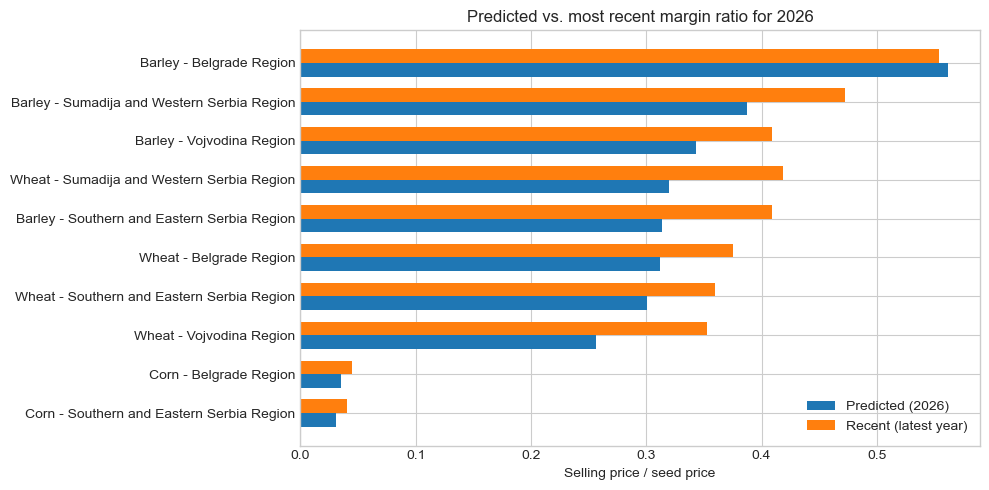

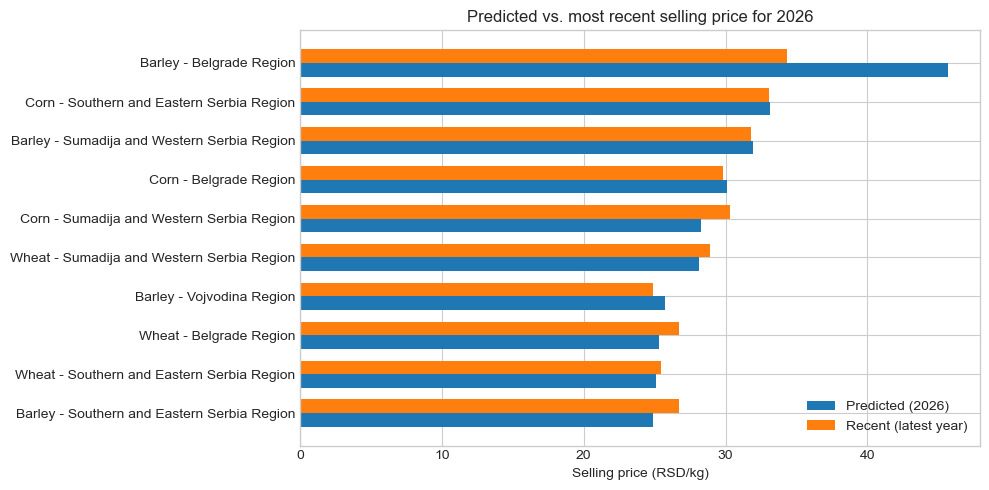

In [6]:
# Hypothesis 3: forecast next-season selling price and margin from trend
forecast_year = int(analysis_df["Year"].max()) + 1
forecast_rows = []

for (crop, region), group in analysis_df.dropna(subset=["Selling price (RSD/kg)", "Margin ratio"]).groupby(["Crop", "Region"]):
    history = group.sort_values("Year").tail(5)
    if len(history) < 3:
        continue

    years = history["Year"]
    price_slope, price_intercept = np.polyfit(years, history["Selling price (RSD/kg)"], 1)
    margin_slope, margin_intercept = np.polyfit(years, history["Margin ratio"], 1)

    forecast_rows.append({
        "Crop": crop,
        "Region": region,
        "Forecast year": forecast_year,
        "Predicted selling price (RSD/kg)": price_slope * forecast_year + price_intercept,
        "Predicted margin ratio": margin_slope * forecast_year + margin_intercept,
        "Current selling price (RSD/kg)": history["Selling price (RSD/kg)"].iloc[-1],
        "Current margin ratio": history["Margin ratio"].iloc[-1],
        "Latest year": int(history["Year"].iloc[-1]),
        "History years": len(history),
    })

forecast_df = pd.DataFrame(forecast_rows)
display(forecast_df.sort_values(["Crop", "Region"]).head(12))


def plot_predicted_vs_current(forecast_df, value_column, title, xlabel):
    """Predicted next-season vs. most recent value, top 10 region-crop combos."""
    fig, ax = plt.subplots(figsize=(10, 5))
    if forecast_df.empty:
        plt.tight_layout()
        plt.show()
        return

    predicted_col = f"Predicted {value_column}"
    current_col = f"Current {value_column}"
    top = forecast_df.sort_values(predicted_col, ascending=False).head(10)
    labels = top["Crop"].astype(str) + " - " + top["Region"].astype(str)

    y = np.arange(len(top))
    bar_height = 0.35
    ax.barh(y + bar_height / 2, top[predicted_col], height=bar_height,
            color="tab:blue", label=f"Predicted ({forecast_year})")
    ax.barh(y - bar_height / 2, top[current_col], height=bar_height,
            color="tab:orange", label="Recent (latest year)")

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_predicted_vs_current(
    forecast_df, "margin ratio",
    title=f"Predicted vs. most recent margin ratio for {forecast_year}",
    xlabel="Selling price / seed price",
)
plot_predicted_vs_current(
    forecast_df, "selling price (RSD/kg)",
    title=f"Predicted vs. most recent selling price for {forecast_year}",
    xlabel="Selling price (RSD/kg)",
)


,Year,Region,City,Crop,Selling price (RSD/kg),Seed price (RSD/kg),Yield (t/ha),Seeding rate (kg/ha),Seed cost per ha (RSD/ha),Gross revenue per ha (RSD/ha),Net margin per ha (RSD/ha)
0,2010,Belgrade Region,Beograd,Corn,16.223214,278.425926,6.0,30,8352.777778,97339.285714,88986.507937
1,2010,Southern and Eastern Serbia Region,Niš,Corn,18.115385,261.428571,5.3,30,7842.857143,96011.538462,88168.681319
2,2010,Southern and Eastern Serbia Region,Pirot,Corn,19.788462,259.500000,5.3,30,7785.000000,104878.846154,97093.846154
3,2010,Southern and Eastern Serbia Region,Požarevac,Corn,15.027778,268.910714,5.3,30,8067.321429,79647.222222,71579.900794
4,2010,Southern and Eastern Serbia Region,Smederevo,Corn,15.545455,271.944444,5.3,30,8158.333333,82390.909091,74232.575758


,Crop,Region,Mean gross revenue per ha (RSD/ha),Mean seed cost per ha (RSD/ha),Mean net margin per ha (RSD/ha),Cities
1,Barley,Sumadija and Western Serbia Region,81765.766967,6160.661926,75605.105041,4
0,Corn,Vojvodina Region,96177.548197,8927.600370,87249.947827,7
2,Wheat,Vojvodina Region,80488.368695,8116.891830,72371.476865,7


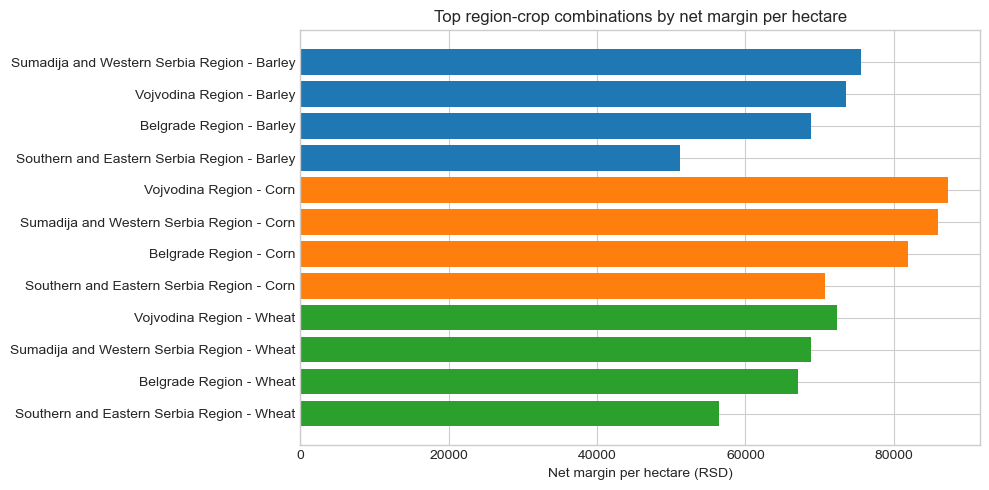

In [7]:
# Hypothesis 4: net margin ranking, computed per city then averaged to region.
# merge_dataset.py averages all (city, date) quotes together, over-weighting
# frequently-quoted cities; reducing each city to one price first makes every
# city count equally. SORS yield exists only at region level.
from paths import STIPS_SELLING_PRICES_CLEAN, STIPS_SEED_PRICES_CLEAN
from merge_dataset import load_selling_prices, load_seed_prices

city_selling_price = (
    load_selling_prices(STIPS_SELLING_PRICES_CLEAN)
    .groupby(["Year", "Region", "City", "Crop"])["price_rsd"]
    .mean()
    .rename("Selling price (RSD/kg)")
    .reset_index()
)

city_seed_price = (
    load_seed_prices(STIPS_SEED_PRICES_CLEAN)
    .groupby(["Year", "Region", "City", "Crop"])["seed_price_rsd_per_kg"]
    .mean()
    .rename("Seed price (RSD/kg)")
    .reset_index()
)

# Regional yield reused from analysis_df (SORS has no city breakdown).
regional_yield = analysis_df[["Year", "Region", "Crop", "Yield (t/ha)"]].drop_duplicates()

city_margin = (
    city_selling_price.merge(city_seed_price, on=["Year", "Region", "City", "Crop"], how="inner")
    .merge(regional_yield, on=["Year", "Region", "Crop"], how="inner")
)
city_margin["Seeding rate (kg/ha)"] = city_margin["Crop"].map(SEEDING_RATE_KG_HA)
city_margin["Seed cost per ha (RSD/ha)"] = city_margin["Seed price (RSD/kg)"] * city_margin["Seeding rate (kg/ha)"]
city_margin["Gross revenue per ha (RSD/ha)"] = city_margin["Selling price (RSD/kg)"] * city_margin["Yield (t/ha)"] * 1000
city_margin["Net margin per ha (RSD/ha)"] = city_margin["Gross revenue per ha (RSD/ha)"] - city_margin["Seed cost per ha (RSD/ha)"]
city_margin = city_margin.merge(cpi_2010, on="Year", how="left")
# Deflate per-hectare money to constant 2010 dinars before averaging across years.
_deflator = city_margin["CPI (2010=100)"] / 100
for _col in ["Gross revenue per ha (RSD/ha)", "Seed cost per ha (RSD/ha)", "Net margin per ha (RSD/ha)"]:
    city_margin[_col] = city_margin[_col] / _deflator
city_margin = city_margin.drop(columns="CPI (2010=100)")

display(city_margin.head())

# Average per-city margin to region (equal weight per city)
region_crop_summary = (
    city_margin.groupby(["Crop", "Region"])
    .agg(**{
        "Mean gross revenue per ha (RSD/ha)": ("Gross revenue per ha (RSD/ha)", "mean"),
        "Mean seed cost per ha (RSD/ha)": ("Seed cost per ha (RSD/ha)", "mean"),
        "Mean net margin per ha (RSD/ha)": ("Net margin per ha (RSD/ha)", "mean"),
        "Cities": ("City", "nunique"),
    })
    .reset_index()
)

best_region_by_crop = (
    region_crop_summary.sort_values("Mean net margin per ha (RSD/ha)", ascending=False)
    .groupby("Crop", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
display(best_region_by_crop.sort_values("Crop"))

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = region_crop_summary.sort_values(["Crop", "Mean net margin per ha (RSD/ha)"], ascending=[True, False]).head(12)
for crop, subset in plot_data.groupby("Crop"):
    ax.barh(subset["Region"] + " - " + crop, subset["Mean net margin per ha (RSD/ha)"], label=crop, color=CROP_COLORS[crop])
ax.set_title("Top region-crop combinations by net margin per hectare")
ax.set_xlabel("Net margin per hectare (RSD)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Interpretation of the Four Hypotheses

*All per-hectare monetary figures below are inflation-adjusted to constant 2010 dinars using the SORS Consumer Price Index (CPI), so they are comparable across years; per-kg prices are shown at the nominal price observed each year.*

1. **Selling price vs. seed price relationship**

   All three crops show the same overall direction, the selling-price-to-seed-price ratio declined over time, especially after the mid-2010s, and all three bottom out in the 2023-2025 window: wheat and barley reach their series lows in 2023, corn in 2024-2025. That means producers faced a less favorable price relationship in most later years, even though the trend was not perfectly monotonic. All three crops also show a shared spike in 2022, likely reflecting the global commodity price shock that year, but it is a one-year reversal rather than a lasting improvement, since the downward trend resumes immediately afterward. Corn's seed price nearly tripled over the period while its market price only roughly doubled, a much sharper increase than wheat or barley, whose seed prices roughly doubled while their market prices stayed roughly flat. This asymmetry, input costs rising much faster than output prices, is likely the main driver of the margin squeeze across all three crops, and points to input-cost inflation, not weak output prices. Because corn seed and grain prices operate on a very different absolute scale than wheat/barley, each crop is analyzed separately rather than blended into one figure. Measured in RSD/kg, corn's seed price looks far more expensive than wheat's or barley's, but corn is sown at a much lower rate per hectare. Once converted to seed cost per hectare, all three crops sit in a broadly similar range for most of the period, so the RSD/kg comparison alone overstates how much more expensive corn seed actually is to a producer.

2. **Yield vs. selling price**

   The relationship is tested within each year, since a raw correlation across years would mix genuine regional variation with unrelated year-to-year price trends (inflation, the 2022 shock), which can distort or even flip the sign of the result. After removing the yearly trend, all three crops show a negative relationship: corn most strongly, then wheat and barley. This is more economically coherent than the simple raw correlation, which showed a misleading positive relationship for wheat and barley driven by the shared trend rather than a true regional effect. The pattern also holds up in the noisier year-by-year view (n=4 per year), which fluctuates a great deal but averages in the same direction as the demeaned estimate for each crop, supporting that the negative relationship is real rather than an artifact of the demeaning method. Practically, this means a strong regional harvest tends to coincide with a lower price that same year, most noticeably for corn, a pattern relevant to storage and sale timing decisions, not just planting choices.

3. **Next-season forecast**

   A simple historical trend on the last 5 years of data predicts 2026 selling prices and margin ratios per crop-region. Corn's predicted margin ratio stays low across all regions, consistent with the declining trend in point 1. Wheat and barley predictions vary more by region, but nearly every region-crop combination is forecast to sit lower than its most recent actual value, consistent with that same declining trend rather than a plateau. One result stands out from this pattern: Belgrade Region's barley forecast is far above every other region-crop combination. Belgrade Region has the smallest barley-growing area of the four regions, so its history is noisier, and in this case, a missing 2025 selling price shifts the fitted window to 2020–2024 instead of 2021–2025, a period more centered on the 2022 price spike, which pulls the trend line up. A short linear fit is especially sensitive to this kind of window shift. More broadly, regions with smaller growing areas have noisier price histories in general, so any published forecast should carry a confidence flag tied to data reliability, not just be taken at face value, and Belgrade's barley result specifically should be treated as a caution about forecast reliability in low-volume regions, not as a genuine prediction.

4. **Region-crop net margin ranking**

   Combining gross revenue per hectare with seed cost per hectare gives a net margin figure, still not a full profit measure since fertilizer, pesticide, and labor costs are excluded, but a better proxy than gross revenue alone. Margin is computed per city first (using that city's own STIPS price and its region's SORS yield) and only then averaged up to the region, so that cities with more frequent price quotes do not implicitly outweigh cities with sparser data. The strongest combinations are corn in Vojvodina, wheat in Vojvodina, and barley in Sumadija and Western Serbia, since seed cost differences between regions are small relative to the differences in revenue. Corn keeps the highest net margin per hectare of the three crops even after its seed cost is subtracted.

## Policy takeaway

Producer margins have narrowed for all three crops since the early 2010s, most sharply for corn, whose seed cost has grown much faster than its market price, though the gap looks smaller once seed cost is measured per hectare rather than per kilogram. Input-cost inflation, not weak selling prices, is the clearer driver of this squeeze: wheat and barley's market prices stayed roughly flat even as their seed prices roughly doubled. The 2022 price shock offered temporary relief across all crops before the downward trend resumed. The squeeze shows up in the margin itself: net margin per hectare fell for all three crops, by roughly 7% for barley, 16% for corn, and 23% for wheat between 2010-2012 and 2023-2025. Within a given year, higher-yield regions tend to see somewhat lower prices for all three crops, a pattern only visible after removing the shared year-to-year price trend, relevant to storage and sale-timing decisions as much as planting choices. The most net-margin-efficient region is crop-specific (Vojvodina for corn and wheat, Sumadija and Western Serbia for barley). Forecasts should be read as directional trends rather than precise predictions, particularly in smaller-production regions where recent history is volatile, as illustrated by Belgrade's barley forecast.